In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\2d_missegmentation'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

In [7]:
import sys  
sys.path.insert(1,stvelo_path)
from pipelines.simulation_3ode_class import *
from pipelines.metrics import *
from pipelines.preprocessing import Preprocessing
from pipelines.compute_velocity import Velocities
from pipelines.spatial_artifacts import *
from simulating.simulate_spatial_artifacts import *
from pipelines.utils import *

# Input 

In [8]:
config_simulation = {'parameters':{ 'n_obs':1200,
    'n_vars':300,
    'alpha':None,
    'beta':None,
    'nu' :None,
    'gamma':None,
    'alpha_':0,
    't_max':25,
    'noise_model':"normal",
    'noise_level':1,
    }, 

    'options': {'generate_parameters':True,
                'generate_switch_times':True,
                  'save':False,
                  'saving_path':None
                  },
    'coeff_generate_options':{ 
    'corr':[0.4, 0.3, -0.3, 0.4, -0.2, -0.1],
    'sd':[0.6, 0.6, 0.6, 0.6],
    'mean':[np.log(5), np.log(0.46), np.log(0.4), np.log(0.38)]} }


In [9]:
# Order of correlations: [rho_alpha_beta, rho_alpha_nu, rho_alpha_gamma, rho_beta_nu, rho_beta_gamma, rho_nu_gamma]
# Order of sigmas : [sigma_log_alpha, sigma_log_beta, sigma_log_nu, sigma_log_gamma]
# Order of means : [alpha,beta,nu,gamma]

# config_simulation = {'parameters':{ 'n_obs':800,
#     'n_vars':300,
#     'alpha':5,
#     'beta':0.02,
#     'nu' :0.33,
#     'gamma':0.32,
#     'alpha_':0,
#     't_max':20,
#     'noise_model':"normal",
#     'noise_level':2,
#     }, 

#     'options': {'generate_parameters':False,
#                 'generate_switch_times':True,
#                   'save':False,
#                   'saving_path':None
#                   },
#     }


config_preprocessing = {'preprocess_params': {
     'min_counts': 200, 
     'min_cells': 5,
     'n_neighbors': 15,
     'n_pcs': 0,
     'min_dist': 1},
'functions_to_apply': {'filter_cells': True, 
                       'filter_genes': True, 
                       'normalize_total': True,
                       'log1p': True,
                       'pca': True,
                       'neighbors': True,
                       'umap': True,
                       'leiden': True,
                       'moments': True}}


# config_velocity = { 'velocity_types': ['dynamical','deterministic','stochastic','velovi']}
config_velocity = { 'velocity_types': ['deterministic','stochastic','dynamical','velovi'],
                   'velovi_model_params':{'n_hidden':256,
                                    'n_latent':10,
                                    'n_layers':1,
                                    },
                    'velovi_train_params': {'epochs':600,
                                            'lr':0.01,
                                            'weight_decay':0.01,
                                            'early_stop':True,
                                            'batch_size':256}}



config_plotting = {
    'colorsets': ['leiden', 'clusters'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}



# Simulation

In [10]:
simulator = Simulation3ODE(config= config_simulation) 
adata_dict = simulator.simulate_multi_obs_var(n_obs_list=[800,1000,1200], n_vars_list=[300])

mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0.36   0.144 -0.072]
 [ 0.108  0.144  0.36  -0.036]
 [-0.108 -0.072 -0.036  0.36 ]]
6.180038077475812
0.54032909200048
0.44969370398368275
0.46032057799123954
mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0.36   0.144 -0.072]
 [ 0.108  0.144  0.36  -0.036]
 [-0.108 -0.072 -0.036  0.36 ]]
5.7924547701835785
0.5427118738775942
0.48107538592643617
0.47331196924919233
mean values of [alpha,beta,nu,gamma]:[1.6094379124341003, -0.7765287894989963, -0.916290731874155, -0.9675840262617056]
parameters for 300 genes,  generated with the covariance matrix: [[ 0.36   0.144  0.108 -0.108]
 [ 0.144  0

In [14]:
adata_dict = {k: v.copy() for k, v in adata_dict.items() if '_n_c_' in k}

# Spatial artifacts would go here

In [16]:
adata_dict=add_2d_missegmentation_artifacts(adata_dict=adata_dict, cell_radius=10, section_thickness=20, mean_cytoplasmic=0.4, proportion_of_cells_cut=0.01)

Simulating missegmentation artifacts: 100%|██████████| 1200/1200 [00:00<00:00, 4327.50it/s]


In [17]:
adata_dict

{'adata_n_c_800obs_300genes': AnnData object with n_obs × n_vars = 800 × 300
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity',
 'adata_n_c_1000obs_300genes': AnnData object with n_obs × n_vars = 1000 × 300
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity',
 'adata_n_c_1200obs_300genes': AnnData object with n_obs × n_vars = 1200 × 300
     obs: 'true_t'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity',
 'adata_n_c_800obs_300genes_2dseg': AnnData object with n_obs × n_vars = 800 × 300
     obs: 'true_t', 'cyto_missassigned_fraction', 'nuclei_missassigned_fraction', 'clear_cytoplasm_proportion

# Preprocessing

In [18]:
for key, adata in adata_dict.items():
    print(f'{key} is being preprocessed.')
    preprocessor = Preprocessing(adata,config_preprocessing)
    adata_dict[key] = preprocessor.preprocess_data()

adata_n_c_800obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1000obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1200obs_300genes is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_800obs_300genes_2dseg is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1000obs_300genes_2dseg is being preprocessed.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
adata_n_c_1200obs_300gene

# Keep common cells

In [19]:
adata_800 = {k: v.copy() for k, v in adata_dict.items() if '800' in k}
adata_1000 = {k: v.copy() for k, v in adata_dict.items() if '1000' in k}
adata_1200 = {k: v.copy() for k, v in adata_dict.items() if '1200' in k}

In [20]:
adata_800['adata_n_c_800obs_300genes']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [21]:
adata_800['adata_n_c_800obs_300genes_2dseg']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'cyto_missassigned_fraction', 'nuclei_missassigned_fraction', 'clear_cytoplasm_proportion', 'proportion_of_nuclei_included', 'n_counts', 'leiden'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [22]:
adata_800=keep_common_cells(adata_800)
adata_1000=keep_common_cells(adata_1000)
adata_1200=keep_common_cells(adata_1200)

In [ ]:
adata_1200['adata_n_c_1200obs_300genes']

View of AnnData object with n_obs × n_vars = 1000 × 300
    obs: 'true_t', 'n_counts', 'leiden'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

In [24]:
adata_dict = adata_800 | adata_1000 | adata_1200

In [25]:
adata_dict

{'adata_n_c_800obs_300genes': View of AnnData object with n_obs × n_vars = 800 × 300
     obs: 'true_t', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_velocity', 'Ms', 'Mu'
     obsp: 'distances', 'connectivities',
 'adata_n_c_800obs_300genes_2dseg': View of AnnData object with n_obs × n_vars = 800 × 300
     obs: 'true_t', 'cyto_missassigned_fraction', 'nuclei_missassigned_fraction', 'clear_cytoplasm_proportion', 'proportion_of_nuclei_included', 'n_counts', 'leiden'
     var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'unspliced', 'spliced', 'spliced_nuc', 'spliced_cyt', 'true_veloc

# Velocities

In [26]:
velocity_computer = Velocities(adata_dict,config_velocity)
adata_dict_velocity = velocity_computer.compute_velocities()

Using device: cuda
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
recovering dynamics (using 8/24 cores)
    finished (0:00:20) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
dynamical velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for ea

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX A2000 8GB Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 600/600: 100%|██████████| 600/600 [00:51<00:00, 13.97it/s, v_num=1, train_loss_step=-504, train_loss_epoch=-493]  

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [00:51<00:00, 11.76it/s, v_num=1, train_loss_step=-504, train_loss_epoch=-493]
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse 

...

    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
min_max_scaler is working!
Epoch 480/600:  80%|████████  | 480/600 [00:42<00:10, 11.34it/s, v_num=1, train_loss_step=-538, train_loss_epoch=-545]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: -592.074. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity i

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


    finished (0:00:18) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
min_max_scaler is working!
Epoch 492/600:  82%|████████▏ | 492/600 [00:58<00:12,  8.36it/s, v_num=1, train_loss_step=-518, train_loss_epoch=-533] 
Monitored metric elbo_validation did not improve in the last 45 records. Best score: -519.067. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
deterministic velocity is being calculated.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
stochastic velocity 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


    finished (0:00:19) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
min_max_scaler is working!
Epoch 469/600:  78%|███████▊  | 469/600 [00:57<00:15,  8.21it/s, v_num=1, train_loss_step=-580, train_loss_epoch=-567]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: -588.008. Signaling Trainer to stop.
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 12/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Save 

In [27]:
os.getcwd()

saving_path = os.path.join(os.getcwd(),'data','missegmentation')
saving_path_vae = os.path.join(os.getcwd(),'data','vae')

vae = adata_dict_velocity[0]

np.save(os.path.join(saving_path_vae,'missegmentation'), vae) 


adata_dict = adata_dict_velocity[1]

for d in adata_dict.keys():
    print(d)
    adata_dict[d].write(os.path.join(saving_path,d+'.h5ad'))

adata_n_c_800obs_300genes_deterministic
adata_n_c_800obs_300genes_stochastic
adata_n_c_800obs_300genes_dynamical
adata_n_c_800obs_300genes_velovi
adata_n_c_800obs_300genes_2dseg_deterministic
adata_n_c_800obs_300genes_2dseg_stochastic
adata_n_c_800obs_300genes_2dseg_dynamical
adata_n_c_800obs_300genes_2dseg_velovi
adata_n_c_1000obs_300genes_deterministic
adata_n_c_1000obs_300genes_stochastic
adata_n_c_1000obs_300genes_dynamical
adata_n_c_1000obs_300genes_velovi
adata_n_c_1000obs_300genes_2dseg_deterministic
adata_n_c_1000obs_300genes_2dseg_stochastic
adata_n_c_1000obs_300genes_2dseg_dynamical
adata_n_c_1000obs_300genes_2dseg_velovi
adata_n_c_1200obs_300genes_deterministic
adata_n_c_1200obs_300genes_stochastic
adata_n_c_1200obs_300genes_dynamical
adata_n_c_1200obs_300genes_velovi
adata_n_c_1200obs_300genes_2dseg_deterministic
adata_n_c_1200obs_300genes_2dseg_stochastic
adata_n_c_1200obs_300genes_2dseg_dynamical
adata_n_c_1200obs_300genes_2dseg_velovi


# Plotting 

In [52]:
from pipelines.plot import Plotter
import matplotlib.pyplot as plt

In [53]:
saving_plots_path = os.path.join(os.getcwd(),'outputs','plots')
saving_plots_path

'/home/sergio/Jnotebooks/SALMON/github_repo/outputs/plots'

In [66]:
config = {
    'colorsets': ['leiden','true_t'],
    'velocity_embedding_stream': True,
    'velocity_embedding_grid': True,
    'velocity_embedding': True,
    'rank_velocity_genes': True,
    'velocity_confidence': True,
    'velocity_length': True
}

saving_plots_path = os.path.join(os.getcwd(),'outputs','plots')

# Create an instance of the class
plotter = Plotter(adata_dict=adata_dict_velocity, config=config, saving_path=saving_plots_path,saving_format='pdf')

# Generate the plots
plotter.generate_plots(save=True)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)


# Save results (if needed)

In [16]:
saving_adata_path=os.path.join(saving_plots_path,'adata')
if not os.path.exists(saving_adata_path):
        os.mkdir(saving_adata_path)
for d in adata_dict_velocity.keys():
    print(d)
    adata_dict_velocity[d].write(os.path.join(saving_adata_path,d+'.h5ad'))

NameError: name 'saving_plots_path' is not defined

# Cosine similiarity against ground truth

In [55]:
adata_dict_velocity,cosim_velo_by_gene=correlation_vs_true_velocity(adata_dict_velocity,mode='by_gene')
adata_dict_velocity,cosim_velo_by_cell=correlation_vs_true_velocity(adata_dict_velocity,mode='by_cell')

100%|█████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:00<00:00, 2623.96it/s]


In [56]:
cosim_velo_by_gene=cosim_velo_by_gene.loc[:,np.sum(cosim_velo_by_gene.isna(),axis=0)==0]

Text(0, 0.5, 'Modality')

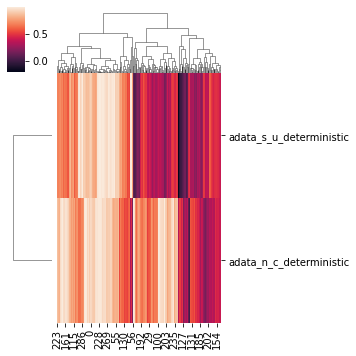

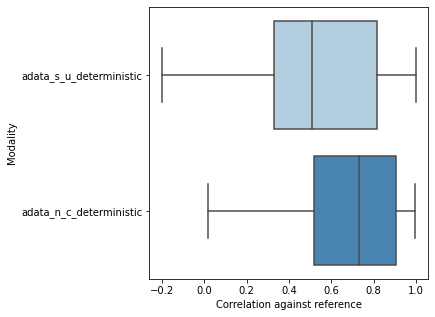

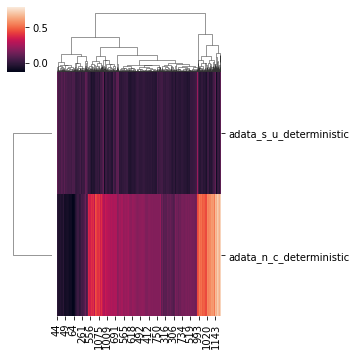

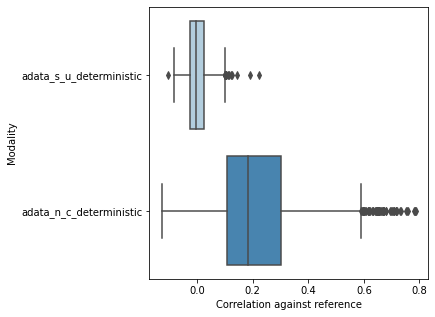

In [57]:
# velo mse
sns.clustermap(cosim_velo_by_gene.fillna(0).astype(float),figsize=(5,5))
plt.figure(figsize=(5,5))
sns.boxplot(data=cosim_velo_by_gene.fillna(0).stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')

sns.clustermap(cosim_velo_by_cell.astype(float),figsize=(5,5))
plt.figure(figsize=(5,5))
sns.boxplot(data=cosim_velo_by_cell.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')


In [58]:
adata_dict_velocity,cosim_velo_by_gene=cosine_similarity_vs_true_velocity(adata_dict_velocity,mode='by_gene')
adata_dict_velocity,cosim_velo_by_cell=cosine_similarity_vs_true_velocity(adata_dict_velocity,mode='by_cell')
cosim_velo_by_gene=cosim_velo_by_gene.loc[:,np.sum(cosim_velo_by_gene.isna(),axis=0)==0]

100%|█████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:00<00:00, 5534.55it/s]


Text(0, 0.5, 'Modality')

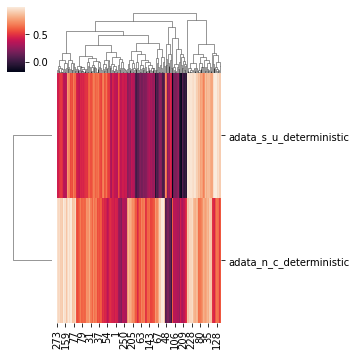

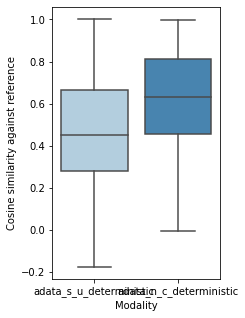

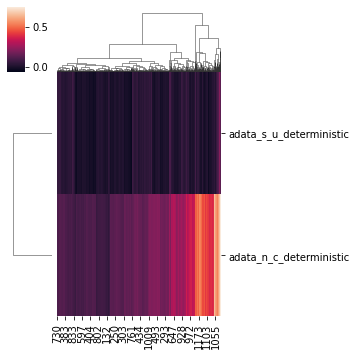

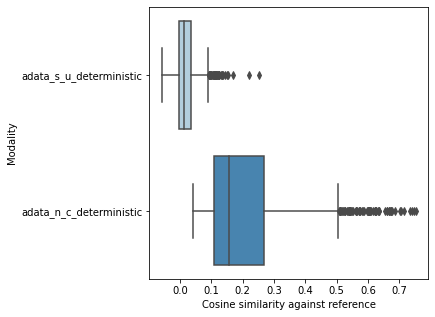

In [64]:
# velo mse
sns.clustermap(cosim_velo_by_gene.fillna(0).astype(float),figsize=(5,5))
plt.figure(figsize=(3,5))
sns.boxplot(data=cosim_velo_by_gene.fillna(0).stack().reset_index(),x='level_0',y=0,palette='Blues')
plt.ylabel('Cosine similarity against reference')
plt.xlabel('Modality')
plt.savefig('cosine_sim.pdf')

sns.clustermap(cosim_velo_by_cell.fillna(0).astype(float),figsize=(5,5))
plt.figure(figsize=(5,5))
sns.boxplot(data=cosim_velo_by_cell.fillna(0).stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Cosine similarity against reference')
plt.ylabel('Modality')

computing velocity graph (using 1/32 cores)


  0%|          | 0/1200 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity graph (using 1/32 cores)


  0%|          | 0/1200 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity graph (using 1/32 cores)


...

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity graph (using 1/32 cores)


  0%|          | 0/1200 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity graph (using 1/32 cores)


  0%|          | 0/1200 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


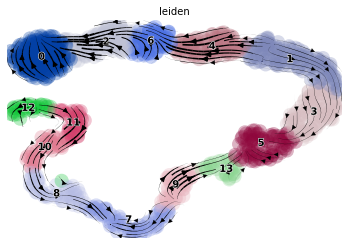

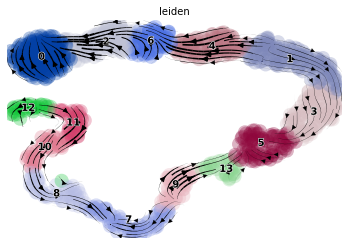

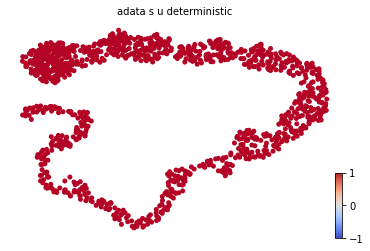

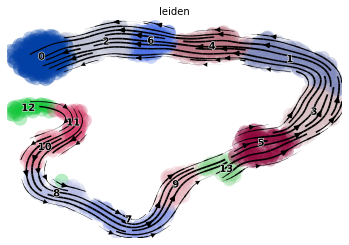

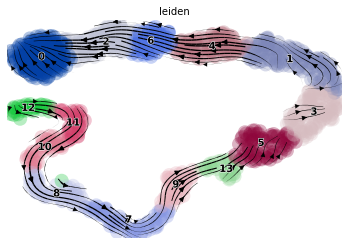

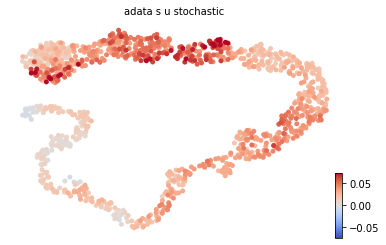

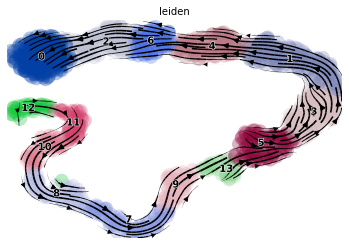

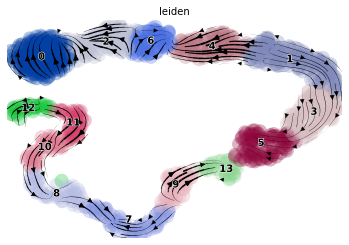

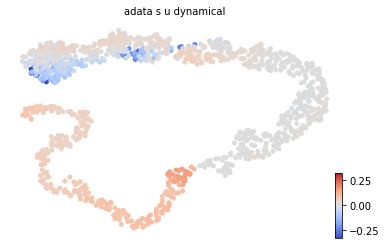

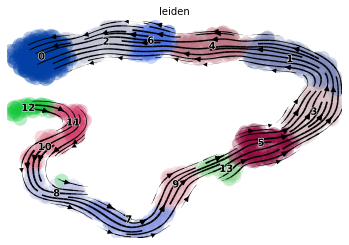

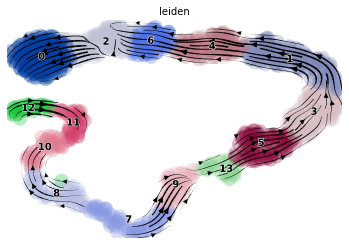

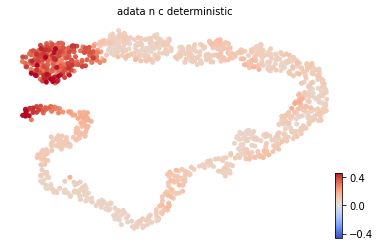

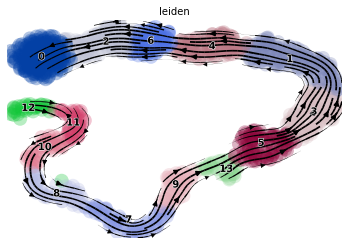

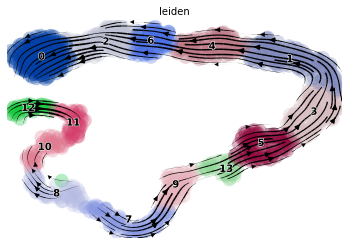

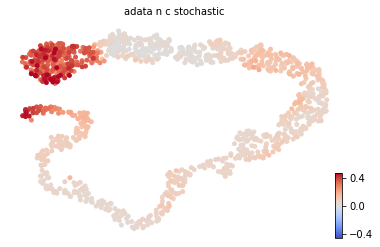

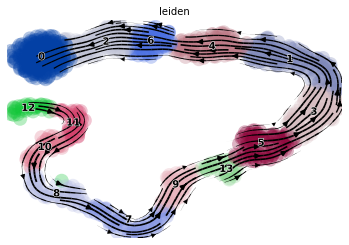

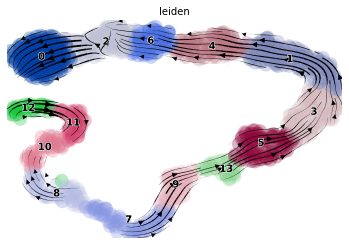

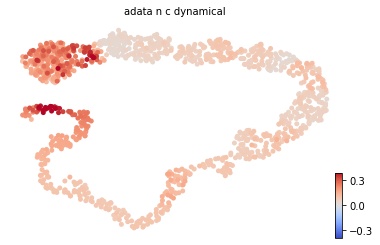

In [45]:
for k,ad in adata_dict_velocity.items():
    scv.tl.velocity_graph(ad)
    scv.pl.velocity_embedding_stream(ad, basis='umap',color='leiden',show=False)   
    ad2=ad.copy()
    ad2.layers['velocity']=ad2.layers['true_velocity']
    scv.tl.velocity_graph(ad2)
    scv.pl.velocity_embedding_stream(ad2, basis='umap',color='leiden',show=False)
    scv.pl.scatter(ad2, c='cosine_similarity_vs_true_velocity', cmap='coolwarm', perc=[1, 99],show=False,title=k)

# Performance metrics (this should also be a function, tbd)

In [17]:
adata_dict=adata_dict_velocity

In [18]:
# confidence 
for d in adata_dict.keys():
    print(d)
    adata_dict[d]=compute_confidence(adata_dict[d])
    
#velocity correlations (by gene or by cell)
velo_corr_bygene=velocity_mean_correlation(adata_dict,mode='by_gene')
velo_corr_bycell=velocity_mean_correlation(adata_dict,mode='by_cell')

# velocity corr against a reference 
velocity_correlation_by_gene=velocity_corr_against_reference(adata_dict,reference='adata_s_u_deterministic', mode= 'by_gene')
velocity_correlation_by_cell=velocity_corr_against_reference(adata_dict,reference='adata_s_u_deterministic', mode= 'by_cell')

#velo mse 
velo_mse_bygene=velocity_mean_mse(adata_dict,mode='by_gene')
velo_mse_bycell=velocity_mean_mse(adata_dict,mode='by_cell')

# velo mse against a reference 
velocity_mse_by_gene=velocity_mse_against_reference(adata_dict,reference='adata_s_u_deterministic', mode= 'by_gene')
velocity_mse_by_cell=velocity_mse_against_reference(adata_dict,reference='adata_s_u_deterministic', mode= 'by_cell')

adata_s_u_deterministic
computing velocity graph (using 2/32 cores)


  0%|          | 0/797 [00:00<?, ?cells/s]

Global seed set to 0
Global seed set to 0


    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_n_c_deterministic
computing velocity graph (using 2/32 cores)


  0%|          | 0/797 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_s_u_2dseg_deterministic
computing velocity graph (using 2/32 cores)


  0%|          | 0/797 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_n_c_2dseg_deterministic
computing velocity graph (using 2/32 cores)


  0%|          | 0/797 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


In [26]:
adata_dict['adata_s_u_deterministic']

AnnData object with n_obs × n_vars = 797 × 200
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'Velocity confidence'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'unspliced', 'spliced', 'Ms', 'Mu', 'velocity'
    obsp: 'distances', 'connectivities'

In [29]:
# velocity sign
sign_accuracies=get_sign_accuracy(adata_dict)


adata_s_u_dynamical


100%|███████████████████████████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 4546.68it/s]


adata_s_u_deterministic


100%|███████████████████████████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 5541.55it/s]


adata_n_c_dynamical


...

100%|███████████████████████████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 5581.36it/s]


adata_n_c_2dseg_dynamical


100%|███████████████████████████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 4760.61it/s]


adata_n_c_2dseg_deterministic


100%|███████████████████████████████████████████████████████████████████████████████| 656/656 [00:00<00:00, 5667.02it/s]


# Plotting metrics

<Axes: xlabel='Velocity confidence', ylabel='velo_type'>

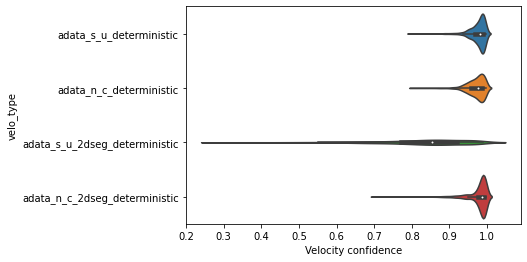

In [19]:
# confidence
import seaborn as sns
confidences=get_confidences(adata_dict)
sns.violinplot(data=confidences,x='Velocity confidence',y='velo_type')

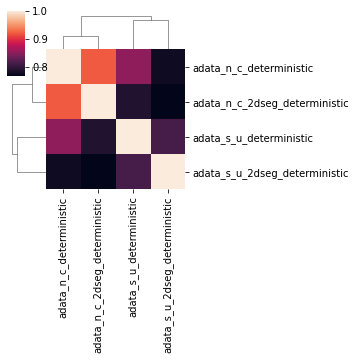

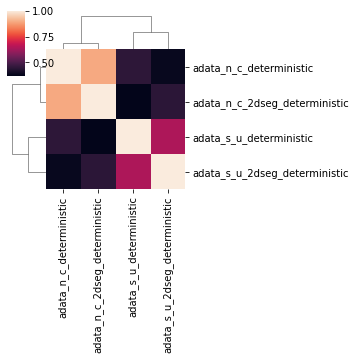

In [20]:
# velocity correlations (by gene or by cell)
sns.clustermap(velo_corr_bygene.astype(float),figsize=(5,5))
sns.clustermap(velo_corr_bycell.astype(float),figsize=(5,5))

Text(0.5, 0, 'Correlation against reference')

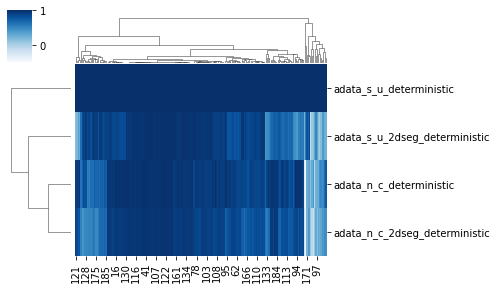

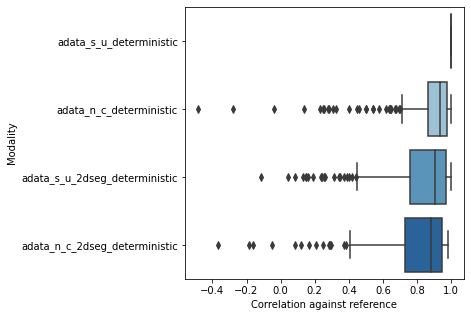

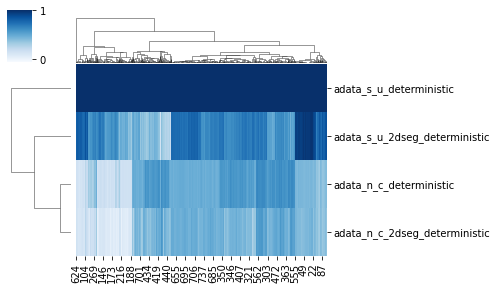

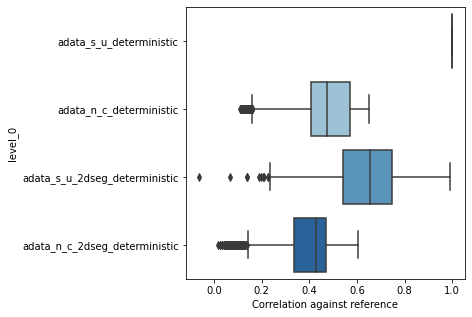

In [21]:
# velocity corr against a reference 
import matplotlib.pyplot as plt
sns.clustermap(velocity_correlation_by_gene.fillna(0),figsize=(7,4),cmap='Blues')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_gene.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')

# same, but by cell
import matplotlib.pyplot as plt
sns.clustermap(velocity_correlation_by_cell.fillna(0),figsize=(7,4),cmap='Blues')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_cell.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')


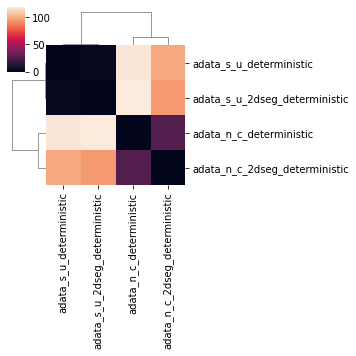

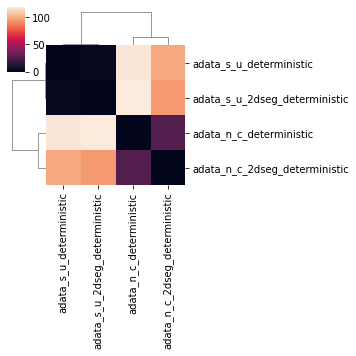

In [22]:
# velo mse
sns.clustermap(velo_mse_bygene.astype(float),figsize=(5,5))
sns.clustermap(velo_mse_bycell.astype(float),figsize=(5,5))

Text(0, 0.5, 'Modality')

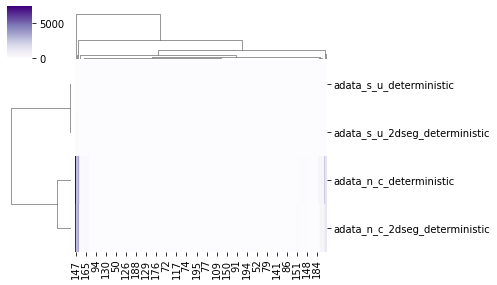

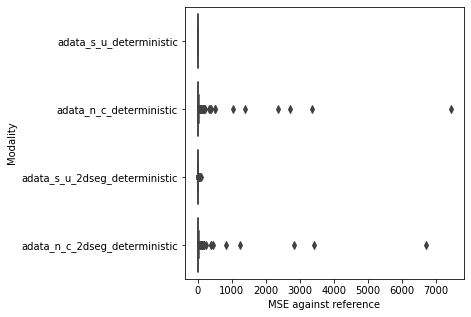

In [23]:
# velo mse against reference 
import matplotlib.pyplot as plt
sns.clustermap(velocity_mse_by_gene.fillna(0),figsize=(7,4),cmap='Purples')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_mse_by_gene.stack().reset_index(),y='level_0',x=0,palette='Purples')
plt.xlabel('MSE against reference')
plt.ylabel('Modality')


In [24]:
# plotting velocity signs
sns.violinplot(data=sign_accuracies,y='Model',x='Accuracy',palette='viridis')

NameError: name 'sign_accuracies' is not defined

# Delete later

In [96]:
adata_dict_velocity['adata_s_u_deterministic'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes,cosine_similarity_vs_true_velocity
0,13.834624,1343.285443,232.887595,31.623856,39.498816,1.0,688,0.079067,0.079067,0.974298,True,0.741995
1,14.449159,15.894777,28.867907,2.199546,1.461791,1.0,707,0.029689,0.029689,0.751124,True,0.231869
2,4.752120,393.898415,35.102883,16.333513,80.105001,1.0,495,0.396262,0.396262,0.990462,True,0.276412
3,4.085570,31.166687,11.560840,16.241620,8.581449,1.0,487,0.509097,0.509097,0.982961,True,0.211853
4,15.485162,1.300195,1.233952,0.153260,0.074992,1.0,758,0.079132,0.079132,-2.602590,False,0.853532
...,...,...,...,...,...,...,...,...,...,...,...,...
195,13.372893,249.598747,99.321954,15.524786,130.493408,1.0,668,0.140121,0.140121,0.982132,True,-0.016599
196,10.415217,1104.027949,80.711692,13.835085,31.237665,1.0,602,0.119088,0.119088,0.989351,True,0.171884
197,13.937646,303.942726,241.850290,102.440952,86.487330,1.0,681,0.199280,0.199280,0.990318,True,0.458111
198,15.283840,402.321382,93.890823,90.901943,56.745893,1.0,694,0.372723,0.372723,0.982311,True,0.409713


In [99]:
adata.['spliced']

array([[0.        , 4.00950396, 0.        , ..., 0.09261861, 1.94880424,
        1.26761344],
       [0.        , 0.58973388, 0.71607854, ..., 0.43988751, 0.41548142,
        0.09534002],
       [2.98911001, 2.47561446, 0.4872882 , ..., 2.91451035, 3.08136411,
        4.93631204],
       ...,
       [4.48094104, 0.        , 0.07922134, ..., 0.97021303, 0.86153482,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        2.56906235],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
for k,ad in adata_dict_velocity.items():
    scv.tl.velocity_graph(ad)
    scv.pl.velocity_embedding_stream(ad, basis='umap',color='leiden',show=False)   
    ad.layers['velocity']=ad.layers['true_velocity']
    scv.tl.velocity_graph(ad)
    scv.pl.velocity_embedding_stream(ad, basis='umap',color='leiden',show=False)
    plt.show()